In [1]:
import sys
from pathlib import Path
from tempfile import TemporaryDirectory
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

import flopy

print(sys.version)
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {mpl.__version__}")
print(f"flopy version: {flopy.__version__}")

3.13.0 | packaged by conda-forge | (main, Oct  8 2024, 19:54:55) [MSC v.1941 64 bit (AMD64)]
numpy version: 2.1.3
matplotlib version: 3.9.2
flopy version: 3.8.2


In [2]:
# Set name of MODFLOW exe
#  assumes executable is in users path statement
exe_name = "mfnwt"
mfexe = exe_name

In [3]:
from pathlib import Path

# Ensure workspace is a Path object
workspace = Path("Watertable_workspace")  # Convert string to Path

# Create the directory if it does not exist
workspace.mkdir(parents=True, exist_ok=True)  

print(f"✅ Directory '{workspace}' is ready.")
modelname = "watertable"

✅ Directory 'Watertable_workspace' is ready.


In [4]:
def analytical_water_table_solution(h1, h2, z, R, K, L, x):
    h = np.zeros((x.shape[0]), float)
    # dx = x[1] - x[0]
    # x -= dx
    b1 = h1 - z
    b2 = h2 - z
    h = np.sqrt(b1**2 - (x / L) * (b1**2 - b2**2) + (R * x / K) * (L - x)) + z
    return h

In [5]:
# model dimensions
nlay, nrow, ncol = 1, 1, 100

# cell spacing
delr = 10.0
delc = 1.0

# domain length
L = 1000.0

# boundary heads
h1 = 2
h2 = 1

# ibound
ibound = np.ones((nlay, nrow, ncol), dtype=int)

# starting heads
strt = np.zeros((nlay, nrow, ncol), dtype=float)
strt[0, 0, 0] = h1
strt[0, 0, -1] = h2

# top of the aquifer
top = 10

# bottom of the aquifer
botm = 0.0

# hydraulic conductivity
hk = 50.0

# location of cell centroids
x = np.arange(0.0, L, delr) + (delr / 2.0)

# location of cell edges
xa = np.arange(0, L + delr, delr)

# recharge rate
rchrate = 0.001

# calculate the head at the cell centroids using the analytical solution function
hac = analytical_water_table_solution(h1, h2, botm, rchrate, hk, L, x)

# calculate the head at the cell edges using the analytical solution function
ha = analytical_water_table_solution(h1, h2, botm, rchrate, hk, L, xa)

# ghbs
# ghb conductance
b1, b2 = 0.5 * (h1 + hac[0]), 0.5 * (h2 + hac[-1])
c1, c2 = hk * b1 * delc / (0.5 * delr), hk * b2 * delc / (0.5 * delr)

# dtype
ghb_dtype = flopy.modflow.ModflowGhb.get_default_dtype()
print(ghb_dtype)

# build ghb recarray
stress_period_data = np.zeros((2), dtype=ghb_dtype)
stress_period_data = stress_period_data.view(np.recarray)

print("stress_period_data: ", stress_period_data)
print("type is: ", type(stress_period_data))

# fill ghb recarray
stress_period_data[0] = (0, 0, 0, h1, c1)
stress_period_data[1] = (0, 0, ncol - 1, h2, c2)

[('k', '<i8'), ('i', '<i8'), ('j', '<i8'), ('bhead', '<f4'), ('cond', '<f4')]
stress_period_data:  [(0, 0, 0, 0., 0.) (0, 0, 0, 0., 0.)]
type is:  <class 'numpy.rec.recarray'>


In [6]:
mf = flopy.modflow.Modflow(
    modelname=modelname, exe_name=mfexe, model_ws=workspace, version="mfnwt"
)
dis = flopy.modflow.ModflowDis(
    mf,
    nlay,
    nrow,
    ncol,
    delr=delr,
    delc=delc,
    top=top,
    botm=botm,
    perlen=1,
    nstp=1,
    steady=True,
)
bas = flopy.modflow.ModflowBas(mf, ibound=ibound, strt=strt)
lpf = flopy.modflow.ModflowUpw(mf, hk=hk, laytyp=1)
ghb = flopy.modflow.ModflowGhb(mf, stress_period_data=stress_period_data)
rch = flopy.modflow.ModflowRch(mf, rech=rchrate, nrchop=1)
oc = flopy.modflow.ModflowOc(mf)
nwt = flopy.modflow.ModflowNwt(mf, linmeth=2, iprnwt=1, options="COMPLEX")
mf.write_input()

# remove existing heads results, if necessary
try:
    (workspace / f"{modelname}.hds").unlink(missing_ok=True)
except:
    pass
# run existing model
success, buff = mf.run_model(silent=True, report=True)
assert success, "Failed to run"
for line in buff:
    print(line)


                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.1.4 4/01/2018                         
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.04.0 09/15/2016                       

 Using NAME file: watertable.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2025/02/04 20:30:08

 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.
 Run end date and time (yyyy/mm/dd hh:mm:ss): 2025/02/04 20:30:08
 Elapsed run time:  0.039 Seconds

  Normal termination of simulation


In [7]:
# Create the headfile object
headfile = workspace / f"{modelname}.hds"
headobj = flopy.utils.HeadFile(headfile, precision="single")
times = headobj.get_times()
head = headobj.get_data(totim=times[-1])

print("✅ Available Time Steps:", times)
print("✅ HGL Data Shape:", head.shape)
print("✅ Sample HGL Data:\n", head)

✅ Available Time Steps: [np.float32(1.0)]
✅ HGL Data Shape: (1, 1, 100)
✅ Sample HGL Data:
 [[[2.0210586 2.061171  2.0995924 2.1364179 2.1717236 2.205581  2.2380533
   2.269199  2.29907   2.3277142 2.355175  2.3814929 2.406704  2.4308417
   2.4539375 2.4760196 2.497114  2.5172453 2.5364358 2.5547063 2.5720758
   2.588562  2.6041815 2.6189492 2.632879  2.6459842 2.6582766 2.669767
   2.6804652 2.690381  2.6995223 2.707897  2.7155118 2.722373  2.7284865
   2.7338743 2.7385268 2.7424479 2.7456408 2.7481089 2.7498538 2.7508774
   2.7511797 2.7507591 2.7496116 2.7477288 2.7450953 2.7416844 2.7374756
   2.7326746 2.726897  2.7204146 2.7134604 2.705729  2.6971884 2.6878371
   2.677679  2.6667151 2.6549437 2.6423597 2.6289551 2.61472   2.599643
   2.5837102 2.5669067 2.5492163 2.5306203 2.5110998 2.4906332 2.4691975
   2.4467676 2.4233165 2.398815  2.373231  2.3465297 2.3186738 2.289622
   2.2593293 2.2277462 2.1948187 2.160487  2.1246848 2.087339  2.0483677
   2.0076795 1.9651712 1.9207264 1.

In [8]:
print(x.shape)  # Expected: (250,)
print(head.shape)  # Expected: Ensure head[0, 0, :] has shape (250,)


(100,)
(1, 1, 100)


Text(0, 0.5, 'Percent Error')

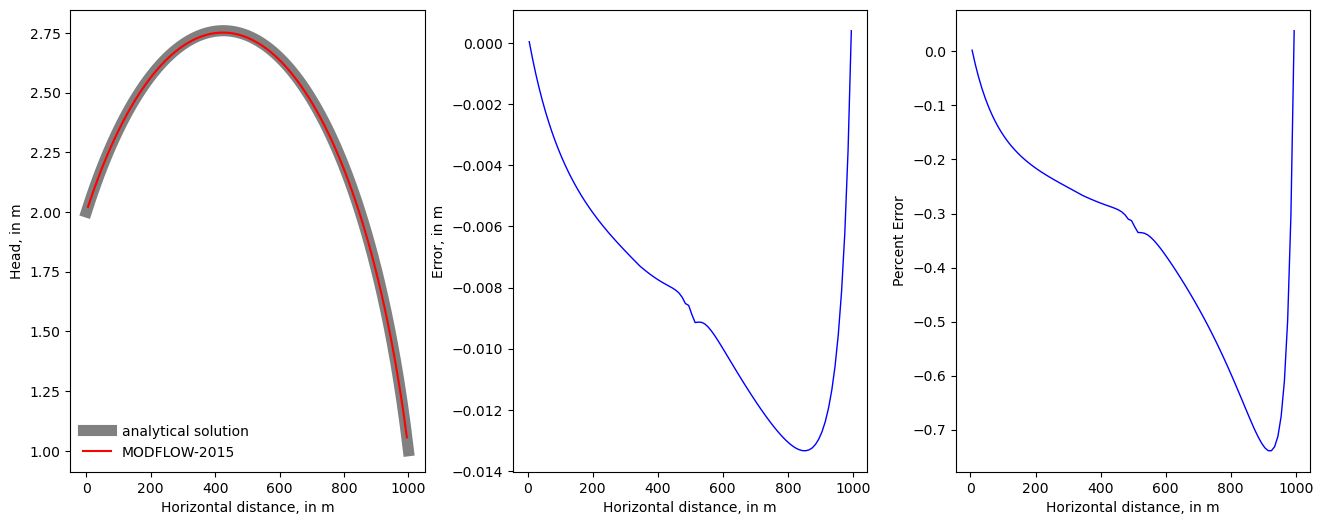

In [9]:
fig = plt.figure(figsize=(16, 6))
fig.subplots_adjust(
    left=None, bottom=None, right=None, top=None, wspace=0.25, hspace=0.25
)

ax = fig.add_subplot(1, 3, 1)
ax.plot(xa, ha, linewidth=8, color="0.5", label="analytical solution")
ax.plot(x, head[0, 0, :], color="red", label="MODFLOW-2015")
leg = ax.legend(loc="lower left")
leg.draw_frame(False)
ax.set_xlabel("Horizontal distance, in m")
ax.set_ylabel("Head, in m")

ax = fig.add_subplot(1, 3, 2)
ax.plot(x, head[0, 0, :] - hac, linewidth=1, color="blue")
ax.set_xlabel("Horizontal distance, in m")
ax.set_ylabel("Error, in m")

ax = fig.add_subplot(1, 3, 3)
ax.plot(x, 100.0 * (head[0, 0, :] - hac) / hac, linewidth=1, color="blue")
ax.set_xlabel("Horizontal distance, in m")
ax.set_ylabel("Percent Error")

In [10]:
from pyswmm import Simulation
import matplotlib.pyplot as plt
from datetime import time

swmm_file = 'modelo_nr.inp'

# Time to filter results (03:00)
target_time = time(3, 0)

# Extract the Troncal profile from the .inp file
with open(swmm_file, 'r', encoding='latin1') as f:
    inp_lines = f.readlines()
    
with Simulation(swmm_file) as sim:
    for step in sim:
        pass


In [11]:
# Extract nodes in the "Troncal" profile
troncal_lines = [line for line in inp_lines if "Troncal" in line]
troncal_pipes = []
for line in troncal_lines:
    nodes = line.split()[1:]  # Extract node IDs after the profile name
    for node in nodes:
        if node.strip() and not node.startswith('"'):  # Filter valid nodes
            troncal_pipes.append(node.strip())

# Remove duplicates while preserving order
troncal_pipes = list(dict.fromkeys(troncal_pipes))
troncal_pipes


['P-376',
 'P-375',
 'P-374',
 'P-373',
 'P-372',
 'P-371',
 'P-386',
 'P-385',
 'P-384',
 'P-383',
 'P-382',
 'P-381',
 'P-379',
 'P-380',
 'P-378',
 'P-377',
 'P-370']

In [12]:
# Extract conduit lengths from the `[CONDUITS]` section
conduit_lengths = {}
in_conduits_section = False

for line in inp_lines:
    if line.startswith("[CONDUITS]"):
        in_conduits_section = True
    elif line.startswith("["):
        in_conduits_section = False
    elif in_conduits_section and line.strip() and not line.startswith(";;"):
        parts = line.split()
        conduit_id = parts[0]
        length = float(parts[3])  # Length is the 4th column in CONDUITS
        conduit_lengths[conduit_id] = length



In [13]:
# Extract conduit diameters from the `[XSECTIONS]` section
conduit_diameter = {}
in_xsections_section = False


for line in inp_lines:
    if line.startswith("[XSECTIONS]"):
        in_xsections_section = True
    elif line.startswith("["):
        in_xsections_section = False
    elif in_xsections_section and line.strip() and not line.startswith(";;"):
        parts = line.split()
        conduit_id = parts[0]
        Geom1 = float(parts[2])  # Diameter is the 3th column in XSECTIONS
        conduit_diameter[conduit_id] = Geom1

conduit_diameter

{'P-370': 0.375,
 'P-371': 0.375,
 'P-372': 0.3,
 'P-373': 0.3,
 'P-374': 0.3,
 'P-375': 0.3,
 'P-376': 0.3,
 'P-377': 0.375,
 'P-378': 0.375,
 'P-379': 0.375,
 'P-380': 0.375,
 'P-381': 0.375,
 'P-382': 0.375,
 'P-383': 0.375,
 'P-384': 0.375,
 'P-385': 0.375,
 'P-386': 0.375,
 'P-21876': 0.3,
 'P-21877': 0.3,
 'P-21878': 0.3,
 'P-21879': 0.3,
 'P-21880': 0.3,
 'P-21881': 0.3,
 'P-21882': 0.3,
 'P-21883': 0.3,
 'P-21884': 0.3,
 'P-21885': 0.3}

In [14]:
# Initialize the result dictionary
troncal_conduit_lengths = {}

# Iterate through troncal_nodes and check if each conduit exists in conduit_lengths
for conduit_name in troncal_pipes:
    if conduit_name in conduit_lengths:
        troncal_conduit_lengths[conduit_name] = conduit_lengths[conduit_name]
    else:
        print(f"Warning: Conduit '{conduit_name}' not found in conduit_lengths.")

troncal_conduit_lengths

{'P-376': 33.2,
 'P-375': 57.4,
 'P-374': 66.6,
 'P-373': 49.4,
 'P-372': 82.6,
 'P-371': 92.8,
 'P-386': 51.9,
 'P-385': 138.7,
 'P-384': 136.2,
 'P-383': 132.6,
 'P-382': 132.6,
 'P-381': 39.2,
 'P-379': 18.5,
 'P-380': 12.1,
 'P-378': 72.5,
 'P-377': 74.8,
 'P-370': 128.0}

In [15]:
from pyswmm import Links

# Iterate through all links in the SWMM simulation
with Simulation(swmm_file) as sim:
    for link in Links(sim):
        conduit_name = link.linkid  # Get the link name (conduit ID)
        connections = link.connections  # Get the connection nodes of the link (inlet and outlet)

        # Check if the conduit is part of troncal_nodes
        if conduit_name in troncal_pipes:
            # Add the conduit length to troncal_conduit_lengths
            troncal_conduit_lengths[conduit_name] = conduit_lengths.get(conduit_name, 0)

In [16]:
from pyswmm import Simulation, Links

# Initialize the refined troncal_conduit_lengths dictionary
refined_troncal_conduit_lengths = {}

# Initialize cumulative length
cumulative_length = 0.0

# Iterate through troncal_nodes to ensure the correct order
with Simulation(swmm_file) as sim:
    for conduit_name in troncal_pipes:  # Iterate over troncal_nodes for the correct order
        # Find the corresponding link in the simulation
        try:
            link = Links(sim)[conduit_name]  # Get the link object using the conduit name
            connections = link.connections  # Get the connection nodes of the link (inlet and outlet)
            length = conduit_lengths.get(conduit_name, 0)  # Get the length of the conduit
            diameter = conduit_diameter.get(conduit_name,0)

            # Update cumulative length
            cumulative_length += length

            # Add details to the refined dictionary
            refined_troncal_conduit_lengths[conduit_name] = {
                "length": round(length, 1),  # Round to one decimal
                "inlet_node": connections[0],  # First node of the connection
                "outlet_node": connections[1],  # Second node of the connection
                "acum_length": round(cumulative_length, 1),  # Cumulative length
                "diameter": round(diameter, 3),  # Diameter
            }


            # Debugging output (optional)
            print(f"Added conduit '{conduit_name}': {refined_troncal_conduit_lengths[conduit_name]}")

        except KeyError:
            print(f"Warning: Conduit '{conduit_name}' not found in the simulation.")

Added conduit 'P-376': {'length': 33.2, 'inlet_node': 'ALP14', 'outlet_node': 'ALP13A', 'acum_length': 33.2, 'diameter': 0.3}
Added conduit 'P-375': {'length': 57.4, 'inlet_node': 'ALP13A', 'outlet_node': 'ALP13', 'acum_length': 90.6, 'diameter': 0.3}
Added conduit 'P-374': {'length': 66.6, 'inlet_node': 'ALP13', 'outlet_node': 'ALP12', 'acum_length': 157.2, 'diameter': 0.3}
Added conduit 'P-373': {'length': 49.4, 'inlet_node': 'ALP12', 'outlet_node': 'ALP11', 'acum_length': 206.6, 'diameter': 0.3}
Added conduit 'P-372': {'length': 82.6, 'inlet_node': 'ALP11', 'outlet_node': 'ALP10', 'acum_length': 289.2, 'diameter': 0.3}
Added conduit 'P-371': {'length': 92.8, 'inlet_node': 'ALP10', 'outlet_node': 'ALP9', 'acum_length': 382.0, 'diameter': 0.375}
Added conduit 'P-386': {'length': 51.9, 'inlet_node': 'ALP9', 'outlet_node': 'ALP8', 'acum_length': 433.9, 'diameter': 0.375}
Added conduit 'P-385': {'length': 138.7, 'inlet_node': 'ALP8', 'outlet_node': 'ALP7', 'acum_length': 572.6, 'diameter

In [17]:
from pyswmm import Simulation, Nodes

# Initialize the dictionary for nodes
nodes_data = {}

# Run the simulation and extract node data
with Simulation(swmm_file) as sim:
    for step in sim:
        for node in Nodes(sim):  # 'node' is the object returned
            # Get node ID
            node_id = node.nodeid

            # Add data to the dictionary
            nodes_data[node_id] = {
                "node_id": node_id,
                "invert_elevation": round(node.invert_elevation, 2),
                "max_depth": round(node.full_depth, 2),
                "current_depth": round(node.depth, 2),
                "hydraulic_head": round(node.head, 2),
                "total_inflow": round(node.total_inflow, 2),
            }

        # Collect data for the current time step only
        break  # Remove this line if you want data for all time steps
        
# Print the resulting dictionary
print("Nodes Data:")
print(nodes_data)

Nodes Data:
{'ALP1': {'node_id': 'ALP1', 'invert_elevation': -3.22, 'max_depth': 5.57, 'current_depth': 0.05, 'hydraulic_head': -3.17, 'total_inflow': 0.11}, 'ALP10': {'node_id': 'ALP10', 'invert_elevation': 0.35, 'max_depth': 4.77, 'current_depth': 0.0, 'hydraulic_head': 0.35, 'total_inflow': 0.0}, 'ALP11': {'node_id': 'ALP11', 'invert_elevation': 2.05, 'max_depth': 4.23, 'current_depth': 0.1, 'hydraulic_head': 2.15, 'total_inflow': 0.29}, 'ALP12': {'node_id': 'ALP12', 'invert_elevation': 2.94, 'max_depth': 4.06, 'current_depth': 0.0, 'hydraulic_head': 2.94, 'total_inflow': 0.0}, 'ALP13': {'node_id': 'ALP13', 'invert_elevation': 3.6, 'max_depth': 4.74, 'current_depth': 0.0, 'hydraulic_head': 3.6, 'total_inflow': 0.0}, 'ALP13A': {'node_id': 'ALP13A', 'invert_elevation': 4.82, 'max_depth': 4.2, 'current_depth': 0.0, 'hydraulic_head': 4.82, 'total_inflow': 0.0}, 'ALP14': {'node_id': 'ALP14', 'invert_elevation': 5.21, 'max_depth': 4.33, 'current_depth': 0.05, 'hydraulic_head': 5.25, 'tota

In [18]:
# Iterate through refined_troncal_conduit_lengths and add new fields
for conduit, data in refined_troncal_conduit_lengths.items():
    outlet_node = data["outlet_node"]  # Get the outlet_node for the conduit

    # Check if outlet_node exists in nodes_data
    if outlet_node in nodes_data:
        # Add invert_elevation and hydraulic_head from nodes_data
        data["outlet_invert_elevation"] = nodes_data[outlet_node]["invert_elevation"]
        data["outlet_hydraulic_head"] = nodes_data[outlet_node]["hydraulic_head"]
        data["outlet_max_depth"] = nodes_data[outlet_node]["max_depth"]
    else:
        # Handle missing outlet_node
        data["outlet_invert_elevation"] = None
        data["outlet_hydraulic_head"] = None
        data["outlet_max_depth"] = None
        print(f"Warning: Outlet node '{outlet_node}' not found in nodes_data.")

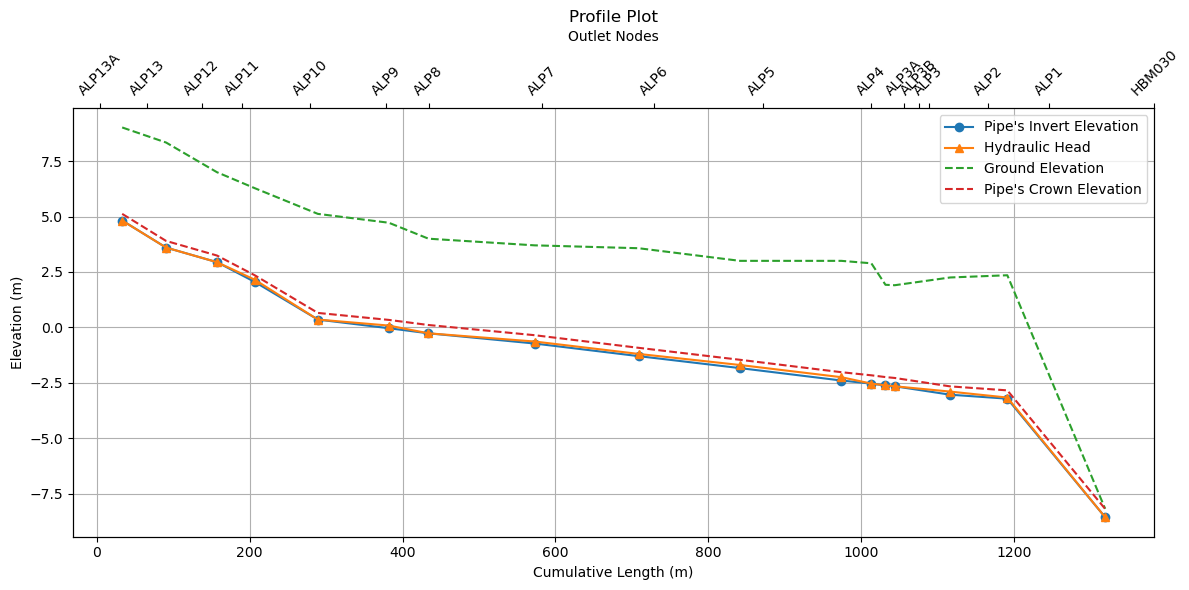

In [19]:
import matplotlib.pyplot as plt

# Extract data for plotting
acum_lengths = []
outlet_nodes = []
outlet_invert_elevations = []
outlet_hydraulic_heads = []
outlet_crown_elevations = []
outlet_ground_elevations = []

for conduit in troncal_pipes:
    if conduit in refined_troncal_conduit_lengths:
        data = refined_troncal_conduit_lengths[conduit]
        acum_lengths.append(data["acum_length"])
        outlet_nodes.append(data["outlet_node"])
        outlet_invert_elevations.append(data["outlet_invert_elevation"])
        outlet_hydraulic_heads.append(data["outlet_hydraulic_head"])
        # Calculate outlet_ground_elevation
        outlet_ground_elevations.append(
            data["outlet_invert_elevation"] + data.get("outlet_max_depth", 0)
        )
        # Calculate outlet_crown_elevation
        outlet_crown_elevations.append(
            data["outlet_invert_elevation"] + data.get("diameter", 0)
        )
# Create the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot outlet elevations
ax1.plot(acum_lengths, outlet_invert_elevations, label="Pipe's Invert Elevation", marker="o")
ax1.plot(acum_lengths, outlet_hydraulic_heads, label="Hydraulic Head", marker="^")
ax1.plot(acum_lengths, outlet_ground_elevations, label="Ground Elevation", linestyle="--")
ax1.plot(acum_lengths, outlet_crown_elevations, label="Pipe's Crown Elevation", linestyle="--")

# Customize the primary X-axis (Lower X-axis: acum_length)
ax1.set_xlabel("Cumulative Length (m)")
ax1.set_ylabel("Elevation (m)")
ax1.grid()
ax1.legend()

# Add secondary X-axis (Upper X-axis: outlet_node)
ax2 = ax1.twiny()
ax2.set_xticks(acum_lengths)
ax2.set_xticklabels(outlet_nodes, rotation=45)
ax2.set_xlabel("Outlet Nodes")

# Adjust layout
plt.title("Profile Plot")
plt.tight_layout()

# Show the plot
plt.show()

In [20]:
outlet_nodes

['ALP13A',
 'ALP13',
 'ALP12',
 'ALP11',
 'ALP10',
 'ALP9',
 'ALP8',
 'ALP7',
 'ALP6',
 'ALP5',
 'ALP4',
 'ALP3A',
 'ALP3B',
 'ALP3',
 'ALP2',
 'ALP1',
 'HBM030']

In [21]:
import numpy as np

# Example: Creating a 2D array that should be 1D
array_original = head  # Example of a non-1D array

# Check if 1D, if not, convert it
if array_original.ndim != 1:
    array_original = array_original.ravel()  # Ensures 1D

print("Shape of array_original:", array_original.shape)  # Should be (100,)


Shape of array_original: (100,)


In [22]:
import numpy as np

# Example data
outlet_nodes 
array_original = head

# Assuming we need to map outlet_notes to specific indices in head
array_reference = np.array(outlet_nodes)

new_size = len(array_reference)


x_original = np.linspace(0, 1, 100)  # Índices originales lenght 100
x_nuevo = np.linspace(0, 1, new_size)

array_original = np.asarray(array_original).flatten()
x_original = np.asarray(x_original).flatten()


# Aplicar interpolación
array_reduced = np.interp(x_nuevo, x_original, array_original)

# Creating the dictionary
watertable_dict = {outlet_nodes[i]: array_reduced[i] for i in range(len(outlet_nodes))}


# Print the dictionary
print(watertable_dict)


{'ALP13A': np.float64(2.0210585594177246), 'ALP13': np.float64(2.24389311671257), 'ALP12': np.float64(2.4157555997371674), 'ALP11': np.float64(2.5467129945755005), 'ALP10': np.float64(2.642707884311676), 'ALP9': np.float64(2.7073735296726227), 'ALP8': np.float64(2.742846965789795), 'ALP7': np.float64(2.7504005283117294), 'ALP6': np.float64(2.7297857999801636), 'ALP5': np.float64(2.680853456258774), 'ALP4': np.float64(2.6015276312828064), 'ALP3A': np.float64(2.4892935156822205), 'ALP3B': np.float64(2.3395657539367676), 'ALP3': np.float64(2.1448235064744954), 'ALP2': np.float64(1.8916554450988774), 'ALP1': np.float64(1.5530657470226292), 'HBM030': np.float64(1.0561023950576782)}


In [23]:
import numpy as np

for node_id in watertable_dict:
    if node_id in nodes_data:
        # Ensure the value is a dictionary before assignment
        if isinstance(watertable_dict[node_id], dict):
            watertable_dict[node_id]["hydraulic_head"] = nodes_data[node_id]["hydraulic_head"]
        else:
            # Convert it into a dictionary if it's not already one
            watertable_dict[node_id] = {
                "original_value": watertable_dict[node_id],  # Store previous value
                "hydraulic_head": nodes_data[node_id]["hydraulic_head"]
            }

print(watertable_dict)


{'ALP13A': {'original_value': np.float64(2.0210585594177246), 'hydraulic_head': 4.82}, 'ALP13': {'original_value': np.float64(2.24389311671257), 'hydraulic_head': 3.6}, 'ALP12': {'original_value': np.float64(2.4157555997371674), 'hydraulic_head': 2.94}, 'ALP11': {'original_value': np.float64(2.5467129945755005), 'hydraulic_head': 2.15}, 'ALP10': {'original_value': np.float64(2.642707884311676), 'hydraulic_head': 0.35}, 'ALP9': {'original_value': np.float64(2.7073735296726227), 'hydraulic_head': 0.08}, 'ALP8': {'original_value': np.float64(2.742846965789795), 'hydraulic_head': -0.27}, 'ALP7': {'original_value': np.float64(2.7504005283117294), 'hydraulic_head': -0.64}, 'ALP6': {'original_value': np.float64(2.7297857999801636), 'hydraulic_head': -1.2}, 'ALP5': {'original_value': np.float64(2.680853456258774), 'hydraulic_head': -1.7}, 'ALP4': {'original_value': np.float64(2.6015276312828064), 'hydraulic_head': -2.25}, 'ALP3A': {'original_value': np.float64(2.4892935156822205), 'hydraulic_h

In [24]:
# Add Length to watertable dictionary
watertable_dict 

refined_troncal_conduit_lengths 

# Add length to watertable_dict where inlet_node matches node_id
for conduit_id, conduit_data in refined_troncal_conduit_lengths.items():
    inlet_node = conduit_data["inlet_node"]
    if inlet_node in watertable_dict:  # Ensure the inlet node exists in watertable_dict
        watertable_dict[inlet_node]["length"] = conduit_data["length"]

# Print the updated dictionary
print(watertable_dict)


{'ALP13A': {'original_value': np.float64(2.0210585594177246), 'hydraulic_head': 4.82, 'length': 57.4}, 'ALP13': {'original_value': np.float64(2.24389311671257), 'hydraulic_head': 3.6, 'length': 66.6}, 'ALP12': {'original_value': np.float64(2.4157555997371674), 'hydraulic_head': 2.94, 'length': 49.4}, 'ALP11': {'original_value': np.float64(2.5467129945755005), 'hydraulic_head': 2.15, 'length': 82.6}, 'ALP10': {'original_value': np.float64(2.642707884311676), 'hydraulic_head': 0.35, 'length': 92.8}, 'ALP9': {'original_value': np.float64(2.7073735296726227), 'hydraulic_head': 0.08, 'length': 51.9}, 'ALP8': {'original_value': np.float64(2.742846965789795), 'hydraulic_head': -0.27, 'length': 138.7}, 'ALP7': {'original_value': np.float64(2.7504005283117294), 'hydraulic_head': -0.64, 'length': 136.2}, 'ALP6': {'original_value': np.float64(2.7297857999801636), 'hydraulic_head': -1.2, 'length': 132.6}, 'ALP5': {'original_value': np.float64(2.680853456258774), 'hydraulic_head': -1.7, 'length': 1

In [25]:
# Add diameter to watertable dictionary
watertable_dict 

refined_troncal_conduit_lengths 

# Add length to watertable_dict where inlet_node matches node_id
for conduit_id, conduit_data in refined_troncal_conduit_lengths.items():
    inlet_node = conduit_data["inlet_node"]
    if inlet_node in watertable_dict:  # Ensure the inlet node exists in watertable_dict
        watertable_dict[inlet_node]["diameter"] = conduit_data["diameter"]

# Print the updated dictionary
print(watertable_dict)

{'ALP13A': {'original_value': np.float64(2.0210585594177246), 'hydraulic_head': 4.82, 'length': 57.4, 'diameter': 0.3}, 'ALP13': {'original_value': np.float64(2.24389311671257), 'hydraulic_head': 3.6, 'length': 66.6, 'diameter': 0.3}, 'ALP12': {'original_value': np.float64(2.4157555997371674), 'hydraulic_head': 2.94, 'length': 49.4, 'diameter': 0.3}, 'ALP11': {'original_value': np.float64(2.5467129945755005), 'hydraulic_head': 2.15, 'length': 82.6, 'diameter': 0.3}, 'ALP10': {'original_value': np.float64(2.642707884311676), 'hydraulic_head': 0.35, 'length': 92.8, 'diameter': 0.375}, 'ALP9': {'original_value': np.float64(2.7073735296726227), 'hydraulic_head': 0.08, 'length': 51.9, 'diameter': 0.375}, 'ALP8': {'original_value': np.float64(2.742846965789795), 'hydraulic_head': -0.27, 'length': 138.7, 'diameter': 0.375}, 'ALP7': {'original_value': np.float64(2.7504005283117294), 'hydraulic_head': -0.64, 'length': 136.2, 'diameter': 0.375}, 'ALP6': {'original_value': np.float64(2.7297857999

In [26]:
import numpy as np

# Provided watertable_dict with required data
watertable_dict 

# Constants for the infiltration equation
C_L = 1.0e-3  # Infiltration coefficient sandy soil (s^-1)
k = 1.0  # Exponent (linear case)

# Constants
pi = np.pi  # Value of π

# Compute groundwater infiltration and update watertable_dict
for key, data in watertable_dict.items():
    if "length" in data and "diameter" in data:  # Ensure necessary data exists
        delta_H = data["original_value"] - data["hydraulic_head"]  # Difference in hydraulic head
        L = data["length"]  # Extracted conduit length
        R = data["diameter"] / 4  # Hydraulic radius
        D = data["diameter"]
        
        # Apply Pokrajac and Howard’s equation under "infiltration" in m/s
        infiltration_rate = C_L * (R ** k) * (delta_H / L) if L > 0 else None  # Avoid division by zero
        
        # Groundwater infiltration in L/s
        groundwater_flow = infiltration_rate * pi * D * L * 1000
        
        # Store the infiltration rate in watertable_dict under "infiltration" in m/s
        watertable_dict[key]["infiltration"] = groundwater_flow

# Print the updated dictionary
print("Updated watertable_dict with groundwater infiltration rates:")
for key, value in watertable_dict.items():
    print(f"{key}: {value}")


Updated watertable_dict with groundwater infiltration rates:
ALP13A: {'original_value': np.float64(2.0210585594177246), 'hydraulic_head': 4.82, 'length': 57.4, 'diameter': 0.3, 'infiltration': np.float64(-0.19784551202012943)}
ALP13: {'original_value': np.float64(2.24389311671257), 'hydraulic_head': 3.6, 'length': 66.6, 'diameter': 0.3, 'infiltration': np.float64(-0.09585754699541264)}
ALP12: {'original_value': np.float64(2.4157555997371674), 'hydraulic_head': 2.94, 'length': 49.4, 'diameter': 0.3, 'infiltration': np.float64(-0.03705665302240429)}
ALP11: {'original_value': np.float64(2.5467129945755005), 'hydraulic_head': 2.15, 'length': 82.6, 'diameter': 0.3, 'infiltration': np.float64(0.028041989160194996)}
ALP10: {'original_value': np.float64(2.642707884311676), 'hydraulic_head': 0.35, 'length': 92.8, 'diameter': 0.375, 'infiltration': np.float64(0.2532218289672993)}
ALP9: {'original_value': np.float64(2.7073735296726227), 'hydraulic_head': 0.08, 'length': 51.9, 'diameter': 0.375, '

In [27]:
# Redefine refined_troncal_conduit_lengths
refined_troncal_conduit_lengths 

# Redefine watertable_dict
watertable_dict 

# Update refined_troncal_conduit_lengths with watertable data
for conduit, data in refined_troncal_conduit_lengths.items():
    outlet_node = data["outlet_node"]
    
    # Check if the outlet node exists in watertable_dict
    if outlet_node in watertable_dict:
        # Add watertable level and infiltration to refined_troncal_conduit_lengths
        data["watertable"] = watertable_dict[outlet_node]["original_value"]
        data["infiltration"] = watertable_dict[outlet_node].get("infiltration", None)  # Use None if missing

refined_troncal_conduit_lengths

{'P-376': {'length': 33.2,
  'inlet_node': 'ALP14',
  'outlet_node': 'ALP13A',
  'acum_length': 33.2,
  'diameter': 0.3,
  'outlet_invert_elevation': 4.82,
  'outlet_hydraulic_head': 4.82,
  'outlet_max_depth': 4.2,
  'watertable': np.float64(2.0210585594177246),
  'infiltration': np.float64(-0.19784551202012943)},
 'P-375': {'length': 57.4,
  'inlet_node': 'ALP13A',
  'outlet_node': 'ALP13',
  'acum_length': 90.6,
  'diameter': 0.3,
  'outlet_invert_elevation': 3.6,
  'outlet_hydraulic_head': 3.6,
  'outlet_max_depth': 4.74,
  'watertable': np.float64(2.24389311671257),
  'infiltration': np.float64(-0.09585754699541264)},
 'P-374': {'length': 66.6,
  'inlet_node': 'ALP13',
  'outlet_node': 'ALP12',
  'acum_length': 157.2,
  'diameter': 0.3,
  'outlet_invert_elevation': 2.94,
  'outlet_hydraulic_head': 2.94,
  'outlet_max_depth': 4.06,
  'watertable': np.float64(2.4157555997371674),
  'infiltration': np.float64(-0.03705665302240429)},
 'P-373': {'length': 49.4,
  'inlet_node': 'ALP12',

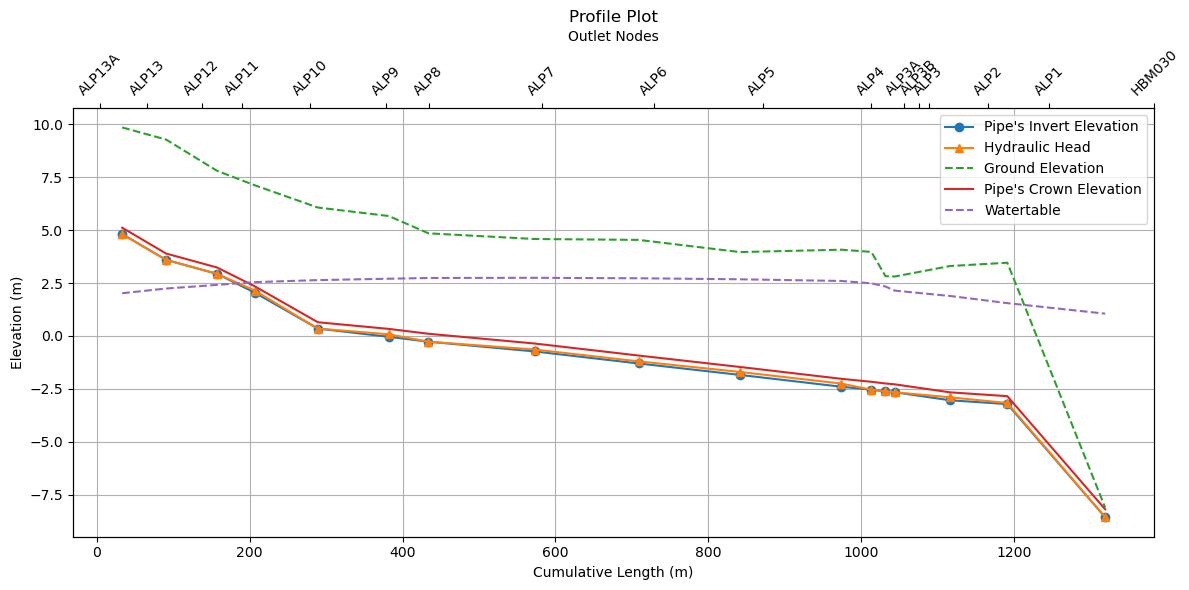

In [28]:
import matplotlib.pyplot as plt

# Extract data for plotting
acum_lengths = []
outlet_nodes = []
outlet_invert_elevations = []
outlet_hydraulic_heads = []
outlet_crown_elevations = []
outlet_ground_elevations = []
outlet_watertable = []

for conduit in troncal_pipes:
    if conduit in refined_troncal_conduit_lengths:
        data = refined_troncal_conduit_lengths[conduit]
        acum_lengths.append(data["acum_length"])
        outlet_nodes.append(data["outlet_node"])
        outlet_invert_elevations.append(data["outlet_invert_elevation"])
        outlet_hydraulic_heads.append(data["outlet_hydraulic_head"])
        outlet_watertable.append(data["watertable"])
        # Calculate outlet_ground_elevation
        outlet_ground_elevations.append(
            data["outlet_invert_elevation"] + 1.2 * data.get("outlet_max_depth", 0)
        )
        # Calculate outlet_crown_elevation
        outlet_crown_elevations.append(
            data["outlet_invert_elevation"] + data.get("diameter", 0)
        )
# Create the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot outlet elevations
ax1.plot(acum_lengths, outlet_invert_elevations, label="Pipe's Invert Elevation", marker="o")
ax1.plot(acum_lengths, outlet_hydraulic_heads, label="Hydraulic Head", marker="^")
ax1.plot(acum_lengths, outlet_ground_elevations, label="Ground Elevation", linestyle="--")
ax1.plot(acum_lengths, outlet_crown_elevations, label="Pipe's Crown Elevation", linestyle="solid")
ax1.plot(acum_lengths, outlet_watertable, label="Watertable", linestyle="--")

# Customize the primary X-axis (Lower X-axis: acum_length)
ax1.set_xlabel("Cumulative Length (m)")
ax1.set_ylabel("Elevation (m)")
ax1.grid()
ax1.legend()

# Add secondary X-axis (Upper X-axis: outlet_node)
ax2 = ax1.twiny()
ax2.set_xticks(acum_lengths)
ax2.set_xticklabels(outlet_nodes, rotation=45)
ax2.set_xlabel("Outlet Nodes")

# Adjust layout
plt.title("Profile Plot")
plt.tight_layout()

# Show the plot
plt.show()

In [29]:
# Extract conduit lengths from the `[CONDUITS]` section
node_loads = {}
in_dwf_section = False

for line in inp_lines:
    if line.startswith("[DWF]"):
        in_dwf_section = True
    elif line.startswith("["):
        in_dwf_section = False
    elif in_dwf_section and line.strip() and not line.startswith(";;"):
        parts = line.split()
        node_id = parts[0]
        load = float(parts[2])  # Length is the 3th column in DWF
        node_loads[node_id] = load

In [30]:
node_loads

{'ALP1': 0.11,
 'ALP11': 0.29,
 'ALP14': 0.13,
 'ALP2': 0.23,
 'ALP4': 0.33,
 'ALP5': 0.3,
 'ALP6': 0.15,
 'ALP7': 0.13,
 'ALP9': 0.24,
 'QNB3': 0.1,
 'QNB7': 0.08,
 'QNB8': 0.15,
 'QNB9': 0.07}

In [31]:
node_loads
watertable_dict

# Create refine_node_loads dictionary by summing node_loads and infiltration from watertable_dict
refine_node_loads = {}

for node, load in node_loads.items():
    infiltration = watertable_dict.get(node, {}).get("infiltration", 0)  # Default to 0 if missing
    refine_node_loads[node] = load + infiltration



In [32]:
refine_node_loads


{'ALP1': np.float64(0.6316466323414489),
 'ALP11': np.float64(0.318041989160195),
 'ALP14': 0.13,
 'ALP2': np.float64(0.7592221324363494),
 'ALP4': np.float64(0.8658348128364595),
 'ALP5': np.float64(0.7838504426239226),
 'ALP6': np.float64(0.5840315460726271),
 'ALP7': np.float64(0.5044582677040615),
 'ALP9': np.float64(0.5301845172324303),
 'QNB3': 0.1,
 'QNB7': 0.08,
 'QNB8': 0.15,
 'QNB9': 0.07}

In [33]:
refine_node_loads["ALP1"]

np.float64(0.6316466323414489)

In [34]:
keys_list = list(refine_node_loads.keys())
keys_list

['ALP1',
 'ALP11',
 'ALP14',
 'ALP2',
 'ALP4',
 'ALP5',
 'ALP6',
 'ALP7',
 'ALP9',
 'QNB3',
 'QNB7',
 'QNB8',
 'QNB9']

In [35]:
from pyswmm import Simulation, SimulationPreConfig


# Create Config Handle
sim_conf = SimulationPreConfig()
 

# Specifying the update parameters
# Parameter Order:
# Section, Object ID, Parameter Index, New Value, Obj Row Num (optional)
sim_conf.add_update_by_token("DWF", "ALP1", 2, refine_node_loads["ALP1"])
sim_conf.add_update_by_token("DWF", "ALP11", 2, refine_node_loads["ALP11"])
sim_conf.add_update_by_token("DWF", "ALP2", 2, refine_node_loads["ALP2"])
sim_conf.add_update_by_token("DWF", "ALP4", 2, refine_node_loads["ALP4"])
sim_conf.add_update_by_token("DWF", "ALP5", 2, refine_node_loads["ALP5"])
sim_conf.add_update_by_token("DWF", "ALP6", 2, refine_node_loads["ALP6"])
sim_conf.add_update_by_token("DWF", "ALP7", 2, refine_node_loads["ALP7"])
sim_conf.add_update_by_token("DWF", "ALP9", 2, refine_node_loads["ALP9"])

with Simulation(swmm_file, sim_preconfig = sim_conf) as sim:
    for step in sim:
        pass

In [36]:
from pyswmm import Simulation
import matplotlib.pyplot as plt
from datetime import time

swmm_file_updated = 'modelo_nr_mod.inp'

# Time to filter results (03:00)
target_time = time(3, 0)

# Extract the Troncal profile from the .inp file
with open(swmm_file_updated, 'r', encoding='latin1') as f:
    inp_lines = f.readlines()
    
with Simulation(swmm_file) as sim:
    for step in sim:
        pass

In [37]:
# Extract conduit lengths from the `[CONDUITS]` section
node_loads_updated = {}
in_dwf_section = False

for line in inp_lines:
    if line.startswith("[DWF]"):
        in_dwf_section = True
    elif line.startswith("["):
        in_dwf_section = False
    elif in_dwf_section and line.strip() and not line.startswith(";;"):
        parts = line.split()
        node_id = parts[0]
        load = float(parts[2])  # Length is the 3th column in DWF
        node_loads_updated[node_id] = load

In [38]:
node_loads_updated

{'ALP1': 0.6316466323414489,
 'ALP11': 0.318041989160195,
 'ALP14': 0.13,
 'ALP2': 0.7592221324363494,
 'ALP4': 0.8658348128364595,
 'ALP5': 0.7838504426239226,
 'ALP6': 0.5840315460726271,
 'ALP7': 0.5044582677040615,
 'ALP9': 0.5301845172324303,
 'QNB3': 0.1,
 'QNB7': 0.08,
 'QNB8': 0.15,
 'QNB9': 0.07}